# T1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import seaborn as sns
import math as mt
from skimage.io import imread, imsave
import statsmodels.api as sm


np.random.seed(42)

Сгенерируем выборку $(\xi_1, \xi_2, \xi_3, \xi_4, \xi_5, \eta)$, размеров $n=50$ где 

$\xi_k$~$R(-1, 1)$, $\eta$~$N(2+3x_1-2x_2+x_3+x_4-x_5, 1.5^2)$

In [19]:
alpha = 0.05
ksi_k = st.uniform(-1,1)
p = 5
n = 50
X = np.array(ksi_k.rvs(size=(n, p)))
eta = np.zeros(n)
for i in range(n):
    eta[i] = st.norm(loc = 2 + 3 * X [i, 0] - 2 * X[i, 1] + X[i, 2] + X[i, 3] - X[i, 4], scale = 1.5).rvs(1)[0]

a) Проверить переменные $\xi_k$ на мультиколлинеарность

In [20]:
# Регрессия на остальные переменные, будем проверять через коэффициент детерминации
print('Коэффициенты детерминации R^2:')
for k in range(5):
    y = X[:, k]
    X_other = np.delete(X, k, axis=1)
    model = sm.OLS(y, sm.add_constant(X_other)).fit()
    print(f'ξ{k+1}: {model.rsquared:.3f}')

Коэффициенты детерминации R^2:
ξ1: 0.134
ξ2: 0.022
ξ3: 0.045
ξ4: 0.042
ξ5: 0.135


**Вывод:** Каждый коэффициент детерминации меньше 0.7 => отсутствует мультиколлинеарность (что логично, так как мы генерили $\xi_k$ независимо)

b) Определить уравнение линейной регрессии $\eta = \beta_0 + \sum_{k=1}^{5} \beta_k \, \xi_k$ и проверить значимость коэффициентов

In [21]:
ons = np.ones((n,1))
PSI = np.hstack((ons, X))
F = PSI.T @ PSI
F_inv = np.linalg.inv(F)
betas = F_inv @ PSI.T @ eta
print('Уравнение линейной регрессии:')
print(f'y = {betas[0]:.3f} + {betas[1]:.3f} * x_1 + {betas[2]:.3f} * x_2 + {betas[3]:.3f} * x_3 + {betas[4]:.3f} * x_4 + {betas[5]:.3f} * x_5')
errors = eta - PSI @ betas
RSS = sum(errors**2)
print('RSS:', RSS)
print('Проверим значимость коэффициентов:')

for i in range(len(betas)):
    delt_T = abs( (betas[i] * np.sqrt(n-p)) / (np.sqrt(RSS * F_inv[i,i])) ) # при верности H0 beta истинная должна быть равна нулю (незначима)
    p_value = 2 * (1 - st.t.cdf(delt_T, df= (n - p)))
    if i == 0:
        print(f'Коэффициент при константе: статистика критерия = {delt_T:.3f}, p_value = {p_value:.3f}, ', 'Коэффициент значим' if p_value < alpha else 'Коэффициент не значим')
    else:
        print(f'Коэффициент при x_{i}: статистика критерия = {delt_T:.3f}, p_value = {p_value:.3f}, ', 'Коэффициент значим' if p_value < alpha else 'Коэффициент не значим')

Уравнение линейной регрессии:
y = 1.267 + 2.048 * x_1 + -1.426 * x_2 + 1.869 * x_3 + 0.433 * x_4 + -3.057 * x_5
RSS: 73.57004085338151
Проверим значимость коэффициентов:
Коэффициент при константе: статистика критерия = 1.438, p_value = 0.157,  Коэффициент не значим
Коэффициент при x_1: статистика критерия = 2.988, p_value = 0.005,  Коэффициент значим
Коэффициент при x_2: статистика критерия = 2.202, p_value = 0.033,  Коэффициент значим
Коэффициент при x_3: статистика критерия = 3.063, p_value = 0.004,  Коэффициент значим
Коэффициент при x_4: статистика критерия = 0.655, p_value = 0.516,  Коэффициент не значим
Коэффициент при x_5: статистика критерия = 4.239, p_value = 0.000,  Коэффициент значим


c) Определить коэффицинет детерминации $R^2$ и проверить его значимость

In [22]:
TSS = sum((eta - np.mean(eta))**2)
R_sq = float(1 - RSS / TSS)
print(f'Коэффициент детерминации R^2: {R_sq:.3f}')
print('Проверим значимость коэффициента детерминации:')
delt_F = (R_sq * (n - p)) / ((1 - R_sq) * (p - 1))
p_value_F = 1 - st.f.cdf(delt_F, dfn= (p - 1), dfd= (n - p))
print(f'Статистика критерия F = {delt_F:.3f}, p_value = {p_value_F:.3f}, ', 'Коэффициент детерминации значим' if p_value_F < alpha else 'Коэффициент детерминации не значим')

Коэффициент детерминации R^2: 0.559
Проверим значимость коэффициента детерминации:
Статистика критерия F = 14.262, p_value = 0.000,  Коэффициент детерминации значим


d) Найти значение в точке $x_k = 0$ и построить 95% доверительный интервал

In [23]:
gamma = 0.95
x_k = np.array([1, 0, 0, 0, 0, 0])
y_pred = x_k @ betas
d = np.sqrt(RSS * (1 + x_k @ F_inv @ x_k.T) / (n - p))
CI_left = y_pred - st.t(n-p).ppf((1 + gamma) / 2) * d
CI_right = y_pred - st.t(n-p).ppf((1 - gamma) / 2) * d
print(f'Доверительный интервал для y_pred : [{CI_left:.3f}, {CI_right:.3f}]')


Доверительный интервал для y_pred : [-1.860, 4.393]


e) Проверить предположение о независимости ошибок измерения

In [24]:
def I(arr):
    inv = 0
    for i in range(len(arr)):
        for j in range(i+1, len(arr)):
            if arr[i]>arr[j]:
                inv += 1
    return inv

I_e = I(errors)
# воспользуемся критерием случайности
delt_I = float((I_e - n*(n-1)/4) / (np.sqrt((n**3)/36)))
p_val = 2 * (1 - st.norm.cdf(abs(delt_I)))

print(f'Статистика критерия I = {delt_I:.3f}')
print(f'p_value = {p_val:.3f}, ', 'Ошибки не являются случайными' if p_val < alpha else 'Ошибки являются случайными')

Статистика критерия I = 0.840
p_value = 0.401,  Ошибки являются случайными


f) Проверить предположение о нормальности ошибок измерения

In [25]:
# воспользуемся критерием Колмогорова для сравнения распределения
def sigm(arr):
    return np.sqrt(np.sum((arr - np.mean(arr))**2)/(len(arr) - 1))

def Nrm(sigma):
    return st.norm(loc = 0, scale = sigma)

sigma_wave = sigm(eta)
F_main = Nrm(sigma_wave)
N = 50000

def bootstrap(N, delt_wave):
    arr = []
    for i in range(N):
        sample = F_main.rvs(size=n)
        F_emp_star = np.array([np.sum(sample[:i]) for i in range(len(sample)+1)]) / n
        sigma_star = sigm(sample)
        F_th_star = np.array([Nrm(sigma_star).cdf(sample[i]) for i in range(len(sample))])
        delt_kolmogorov = float(np.sqrt(n)*np.max([max(np.abs(F_emp_star[i] - F_th_star[i]), np.abs(F_emp_star[i+1] - F_th_star[i])) for i in range(len(sample))])) 
        arr.append(delt_kolmogorov)
    arr = np.sort(np.array(arr))
    p_val = np.sum(arr > delt_wave) / N
    return p_val

F_err = np.array([np.sum(errors[:i]) for i in range(len(errors)+1)]) / n
delt_wave = float(np.sqrt(n)*np.max([max(np.abs(F_main.cdf(errors[i]) - F_err[i+1]), np.abs(F_main.cdf(errors[i]) - F_err[i])) for i in range(len(errors))]))
p_value = bootstrap(N, delt_wave)

print(f'Статистика критерия Колмогорова = {delt_wave:.3f}, p_value = {p_value:.3f}\n', 'Распределение ошибок не является нормальным' if p_value < alpha else 'Распределение ошибок является нормальным')

Статистика критерия Колмогорова = 6.269, p_value = 0.984
 Распределение ошибок является нормальным


g) Исследовать регрессию на выбросы

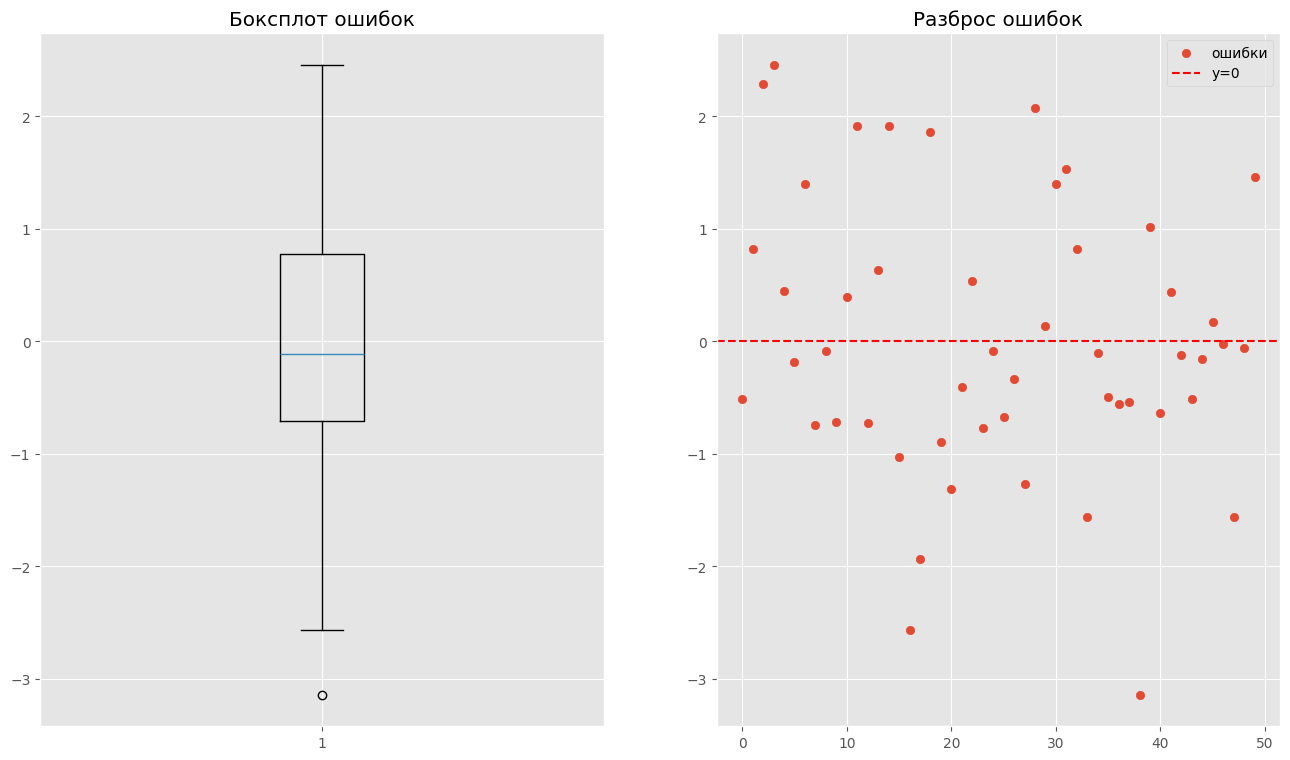

In [26]:
plt.style.use('ggplot')
_, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].boxplot(errors)
ax[0].set_title('Боксплот ошибок')
ax[1].scatter(range(len(errors)), errors, label='ошибки')
ax[1].axhline(0, color='red', linestyle='--', label='y=0')
ax[1].set_title('Разброс ошибок')
ax[1].legend()
plt.show()

h) Провести кросс-проверку регрессии

In [27]:
CVSS = 0

for k in range(n):
    x_kth = X[k, :]
    X_other = np.delete(X, k, axis=0) 
    eta_other = np.delete(eta, k)
    model = sm.OLS(eta_other, sm.add_constant(X_other)).fit()
    y_pred = model.params.dot(np.hstack(([1], x_kth)))
    rss = (eta[k] - y_pred)**2
    CVSS += rss 
R_sq_cv = abs(TSS - CVSS)/TSS


print(f'CVSS = {CVSS:.3f}')
print(f'R^2_cv = {R_sq_cv:.3f}')

CVSS = 94.124
R^2_cv = 0.436


i) Проерить адекватность регрессии, сделав 5 повторных измерений в одной точке

In [28]:
def sigm(arr):
    return np.sqrt(np.sum((arr - np.mean(arr))**2)/(len(arr) - 1))
# проверим адекватность модели, сделав 5 повторных измерений в одной точке
m = 5
x_point = np.array([1, 0, 0, 0, 0, 0])
y_points = st.norm(loc = 2 + 3 * x_point[1] - 2 * x_point[2] + x_point[3] + x_point[4] - x_point[5], scale = 1.5).rvs(m)
sigma_hat = sigm(y_points)**2
delt_adeq = float((RSS)/((n-p)*sigma_hat))
p_val_adeq = 1 - st.f.cdf(delt_adeq, dfn=(n - p), dfd=(m - 1))
print(f'Статистика критерия delta = {delt_adeq:.3f}')
print(f'p_value = {p_val_adeq:.3f}, ', 'Модель не адекватна' if p_val_adeq < alpha else 'Модель адекватна')


Статистика критерия delta = 1.811
p_value = 0.302,  Модель адекватна


j) Удалить переменную, соответствующую наименьшему значимому коэффициенту и повторить пункты b) и c), сравнить уравнения регрессии 

In [29]:
# самый маленький коэффициент детерминации наблюдается у ksi_5, удаляем
X_rem = np.delete(X, 4, axis=1)

ons = np.ones((n,1))
PSI = np.hstack((ons, X_rem))
F = PSI.T @ PSI
F_inv = np.linalg.inv(F)
betas = F_inv @ PSI.T @ eta
print(betas)
print('Уравнение линейной регрессии:')
print(f'y = {betas[0]:.3f} + {betas[1]:.3f} * x_1 + {betas[2]:.3f} * x_2 + {betas[3]:.3f} * x_3 + {betas[4]:.3f} * x_4')
errors = eta - PSI @ betas
RSS_short = sum(errors**2)
print('RSS (short):', RSS_short)
print('Проверим значимость коэффициентов:')

for i in range(len(betas)):
    delt_T = abs( (betas[i] * np.sqrt(n-p)) / (np.sqrt(RSS_short * F_inv[i,i])) ) # при верности H0 beta истинная должна быть равна нулю (незначима)
    p_value = 2 * (1 - st.t.cdf(delt_T, df= (n-p)))
    if i == 0:
        print(f'Коэффициент при константе: статистика критерия = {delt_T:.3f}, p_value = {p_value:.3f}, ', 'Коэффициент значим' if p_value < alpha else 'Коэффициент не значим')
    else:
        print(f'Коэффициент при x_{i}: статистика критерия = {delt_T:.3f}, p_value = {p_value:.3f}, ', 'Коэффициент значим' if p_value < alpha else 'Коэффициент не значим')

TSS = sum((eta - np.mean(eta))**2)
R_sq = float(1 - RSS_short / TSS)

print(f'Коэффициент детерминации R^2: {R_sq:.3f}')
print('Проверим значимость коэффициента детерминации:')

delt_F = (R_sq * (n - p)) / ((1 - R_sq) * (p - 1))
p_value_F = 1 - st.f.cdf(delt_F, dfn=(p - 1), dfd=(n - p))

print(f'Статистика критерия F = {delt_F:.3f}, p_value = {p_value_F:.3f}, ', 'Коэффициент детерминации значим' if p_value_F < alpha else 'Коэффициент детерминации не значим')

[ 3.56473294  2.95831156 -1.58761757  2.40149994  0.8261649 ]
Уравнение линейной регрессии:
y = 3.565 + 2.958 * x_1 + -1.588 * x_2 + 2.401 * x_3 + 0.826 * x_4
RSS (short): 102.94333312934506
Проверим значимость коэффициентов:
Коэффициент при константе: статистика критерия = 4.344, p_value = 0.000,  Коэффициент значим
Коэффициент при x_1: статистика критерия = 3.842, p_value = 0.000,  Коэффициент значим
Коэффициент при x_2: статистика критерия = 2.076, p_value = 0.044,  Коэффициент значим
Коэффициент при x_3: статистика критерия = 3.400, p_value = 0.001,  Коэффициент значим
Коэффициент при x_4: статистика критерия = 1.066, p_value = 0.292,  Коэффициент не значим
Коэффициент детерминации R^2: 0.383
Проверим значимость коэффициента детерминации:
Статистика критерия F = 6.983, p_value = 0.000,  Коэффициент детерминации значим


k) Сравнить уравнение регрессии Бутстрапом

Регрессия, в которой удалили переменную, есть вложенная регрессия исходной, поэтому проверим через бутстрап и доверительный интервал

$H_0: h = 0$

$H_1: h > 0$

In [30]:
# RSSl - длинная, RSSs - короткая
X_Y = np.hstack((X, eta.reshape(-1, 1))) # длинная
X_Y_rem = np.hstack((X_rem, eta.reshape(-1, 1))) # короткая
N_bs = 1000

h_wave = RSS_short - RSS

def bootstrap(N, arr):
    arr_bs = []
    for i in range(N):
        sample = arr[np.random.choice(arr.shape[0], size=arr.shape[0], replace=True)]
        X_bs = sample[:, :-1]
        y_bs = sample[:, -1]
        model_bs = sm.OLS(y_bs, sm.add_constant(X_bs)).fit()
        model_bs_rem = sm.OLS(y_bs, sm.add_constant(np.delete(X_bs, 4, axis=1))).fit()
        RSSl = model_bs.ssr
        RSSs = model_bs_rem.ssr
        h_star = RSSs - RSSl
        delt = h_star - h_wave
        arr_bs.append(delt)
    arr_bs = np.sort(np.array(arr_bs))
    ci_left = arr_bs [49]
    ci_right = arr_bs [999]
    return ci_left, ci_right

ci_left, ci_right = bootstrap(N_bs, X_Y)
print(f'Доверительный интервал для h: {h_wave-ci_right:.3f} < h < {h_wave-ci_left:.3f}]')
print('Проверим, входит ли ноль в доверительный интервал:\n', 'Ноль входит в доверительный интервал, удаление переменной не оправдано (различие незначимо)' \
      if (h_wave-ci_right < 0 < h_wave-ci_left) else 'Ноль не входит в доверительный интервал, удаление переменной оправдано (различие значимо)')

Доверительный интервал для h: -29.515 < h < 49.806]
Проверим, входит ли ноль в доверительный интервал:
 Ноль входит в доверительный интервал, удаление переменной не оправдано (различие незначимо)
